# EXAM SCORE PREDICTIONS

The dataset is gotten from https://www.kaggle.com/datasets/kundanbedmutha/exam-score-prediction-dataset

This dataset provides an extensive and realistic representation of various factors that contribute to student exam performance. It contains 20,000 records, each describing a student’s academic behavior, study habits, lifestyle routines, and exam conditions. These variables collectively help understand how different aspects of a student’s daily life and learning environment influence their exam outcomes.



In this project, A machine learning model would be developed to predict the examination score of score of students depending on the features in the dataset. 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [2]:
#I,port the dataset
df = pd.read_csv("Exam_Score_Prediction.csv")
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [3]:
## Explore and Clean the Data

df.shape

(20000, 13)

In [4]:
df= df.drop(columns="student_id")
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64  
 1   gender            20000 non-null  object 
 2   course            20000 non-null  object 
 3   study_hours       20000 non-null  float64
 4   class_attendance  20000 non-null  float64
 5   internet_access   20000 non-null  object 
 6   sleep_hours       20000 non-null  float64
 7   sleep_quality     20000 non-null  object 
 8   study_method      20000 non-null  object 
 9   facility_rating   20000 non-null  object 
 10  exam_difficulty   20000 non-null  object 
 11  exam_score        20000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 1.8+ MB


In [6]:
df.isnull().sum()

age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

There is no missing values, there is therefore no need for data cleaning. Let's explore thge dataset to see relationships, before we build our model. 

In [7]:
df.describe()

,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,20.473300,4.007604,70.017365,7.00856,62.513225
std,2.284458,2.308313,17.282262,1.73209,18.908491
min,17.000000,0.080000,40.600000,4.10000,19.599000
25%,18.000000,2.000000,55.100000,5.50000,48.800000
50%,20.000000,4.040000,69.900000,7.00000,62.600000
75%,22.000000,6.000000,85.000000,8.50000,76.300000
max,24.000000,7.910000,99.400000,9.90000,100.000000


In [8]:
df.dtypes

age                   int64
gender               object
course               object
study_hours         float64
class_attendance    float64
internet_access      object
sleep_hours         float64
sleep_quality        object
study_method         object
facility_rating      object
exam_difficulty      object
exam_score          float64
dtype: object

## Remove Column of High and Low cadinality

In [9]:
df.select_dtypes("object").nunique()

gender             3
course             7
internet_access    2
sleep_quality      3
study_method       5
facility_rating    3
exam_difficulty    3
dtype: int64

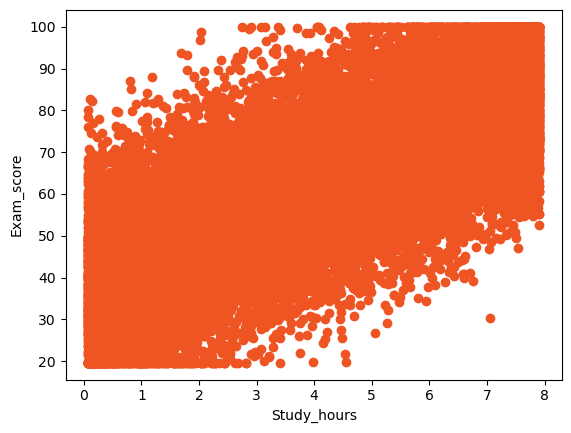

In [10]:
Exam_score = df['exam_score'].values
Study_hours = df['study_hours'].values

# Ploting the scores as scatter plot
plt.scatter(Study_hours, Exam_score, color='#ef5423')
plt.xlabel("Study_hours")
plt.ylabel("Exam_score")
plt.show()

There is a positive relationship between study hours and exam score nevertheless it is 

In [11]:
df.drop(columns= "internet_access", inplace=True) #remove the column it is redundant for building the models
df.head()

,age,gender,course,study_hours,class_attendance,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,9.8,poor,coaching,low,moderate,43.7


In [12]:
sorted(df.columns)

['age',
 'class_attendance',
 'course',
 'exam_difficulty',
 'exam_score',
 'facility_rating',
 'gender',
 'sleep_hours',
 'sleep_quality',
 'study_hours',
 'study_method']

## Multicollinality 

<Axes: >

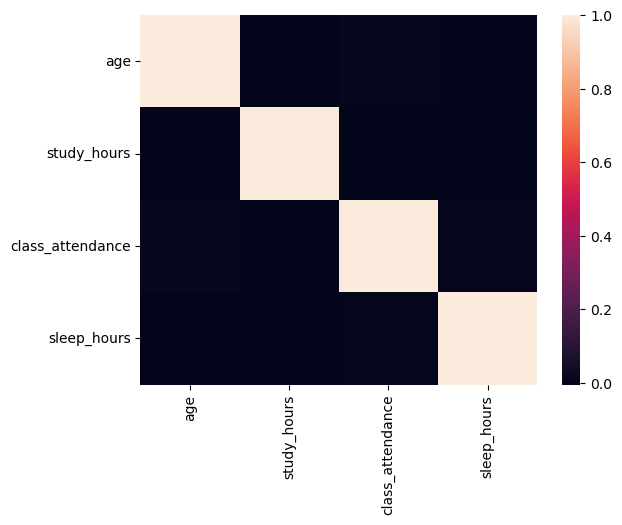

In [13]:
corr = df.select_dtypes("number").drop(columns= 'exam_score').corr()
sns.heatmap(corr)

NO Correlations among the features

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64  
 1   gender            20000 non-null  object 
 2   course            20000 non-null  object 
 3   study_hours       20000 non-null  float64
 4   class_attendance  20000 non-null  float64
 5   sleep_hours       20000 non-null  float64
 6   sleep_quality     20000 non-null  object 
 7   study_method      20000 non-null  object 
 8   facility_rating   20000 non-null  object 
 9   exam_difficulty   20000 non-null  object 
 10  exam_score        20000 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 1.7+ MB


## Data Preprocessing

In [15]:
target = "exam_score"
features = ["age", "gender", "course", "study_hours", "class_attendance", "sleep_hours", "sleep_quality", "study_method", "facility_rating", "exam_difficulty"]

X = df[features]
y = df[target]

len(X) == len(y)

True

In [16]:
up80 = int(len(X)*0.8)

X_train, y_train = X.iloc[:up80], y.iloc[:up80]
X_test, y_test = X.iloc[up80:], y.iloc[up80:]

len(X_train) + len(X_test)

20000

## Build Model

### Baseline

In [17]:
from sklearn.metrics import mean_absolute_error

In [18]:

# Generate baseline of the target value in the train set
y_pred_baseline = [y_train.mean()] * len(y_train)

# Calculate the mean absolute error of the training set
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("mean exam score :", round(y_train.mean(), 2))
print ("Baseline mean absolute error", round(mae_baseline, 2))

mean exam score : 62.54
Baseline mean absolute error 15.49


In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge

In [27]:
model = make_pipeline(
    OneHotEncoder(),
    SimpleImputer(),
    LinearRegression()
)
model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder', OneHotEncoder()),
                ('simpleimputer', SimpleImputer()),
                ('linearregression', LinearRegression())])

### Evaluate

In [28]:
#Generate prediction using trained model 

y_pred_training = model.predict(X_train)

#calculate the mean absolute error of the train pred value
print("Training MAE:", mean_absolute_error(y_train, y_pred_training))

Training MAE: 7.5281143091940566


## Generalizability

In [29]:
y_pred_testing =pd.Series(model.predict(X_test))
y_pred_testing.head()

0    65.195436
1    81.400319
2    55.072191
3    67.680540
4    66.081134
dtype: float64

In [30]:
#calculate the mean absolute error of the test predicted value

print("Test MAE:", mean_absolute_error(y_test, y_pred_testing))

Training MAE: 8.090277777018912


In [31]:
y_test.head()

16000    61.9
16001    80.8
16002    59.4
16003    65.1
16004    60.9
Name: exam_score, dtype: float64